In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
model_df = pd.read_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/expense_features.csv"
)

print(model_df.shape)

(7000, 7)


## Data Validation

In [3]:
model_df.head(5)

,transaction_text,amount,amount_log,amount_bucket,payment_method,transaction_type,category
0,Credit Card Bill Payment Auto Debit Credit Car...,4361.84,8.380879,Large,Auto Debit,Debit,Bills
1,Zepto UPI/Paytm/Zepto,1226.03,7.112352,Medium,Upi,Debit,Groceries
2,Ace Hardware India POS Purchase Ace Hardware I...,523.73,6.262884,Small,Credit Card,Debit,Miscellaneous
3,Zepto UPI/DR/623175732898/Zepto,1290.29,7.163397,Medium,Upi,Debit,Groceries
4,House Rent Payment NEFT Rent Payment,44800.94,10.710007,Large,Neft,Debit,Rent


In [4]:


print("\nMissing values:")
print(model_df.isnull().sum())




Missing values:
transaction_text    0
amount              0
amount_log          0
amount_bucket       0
payment_method      0
transaction_type    0
category            0
dtype: int64


In [5]:
print("\nData types:")
print(model_df.dtypes)


Data types:
transaction_text        str
amount              float64
amount_log          float64
amount_bucket           str
payment_method          str
transaction_type        str
category                str
dtype: object


In [6]:

print("\nDuplicate rows:")
print(model_df.duplicated().sum())


Duplicate rows:
222


In [7]:
print("\nUnique transaction texts:")
print(model_df["transaction_text"].nunique())


Unique transaction texts:
1209


In [8]:

print("\nEmpty transaction texts:")
print(
    (model_df["transaction_text"].astype(str).str.strip() == "").sum()
)


Empty transaction texts:
0


In [9]:
model_df.category.unique()

<StringArray>
[        'Bills',     'Groceries', 'Miscellaneous',          'Rent',
          'Food', 'Entertainment',      'Shopping',          'Fuel',
  'Subscription',        'Salary',     'Insurance',         'Other',
    'Investment']
Length: 13, dtype: str

In [10]:
category_distribution = (
    model_df["category"]
    .value_counts()
    .to_frame("count")
)

category_distribution["percentage"] = (
    category_distribution["count"]
    / len(model_df)
    * 100
).round(2)

print(category_distribution)

               count  percentage
category                        
Bills           2059       29.41
Food            1328       18.97
Groceries        912       13.03
Shopping         550        7.86
Other            435        6.21
Fuel             423        6.04
Miscellaneous    358        5.11
Subscription     242        3.46
Salary           173        2.47
Entertainment    167        2.39
Rent             165        2.36
Insurance        152        2.17
Investment        36        0.51


## EDA

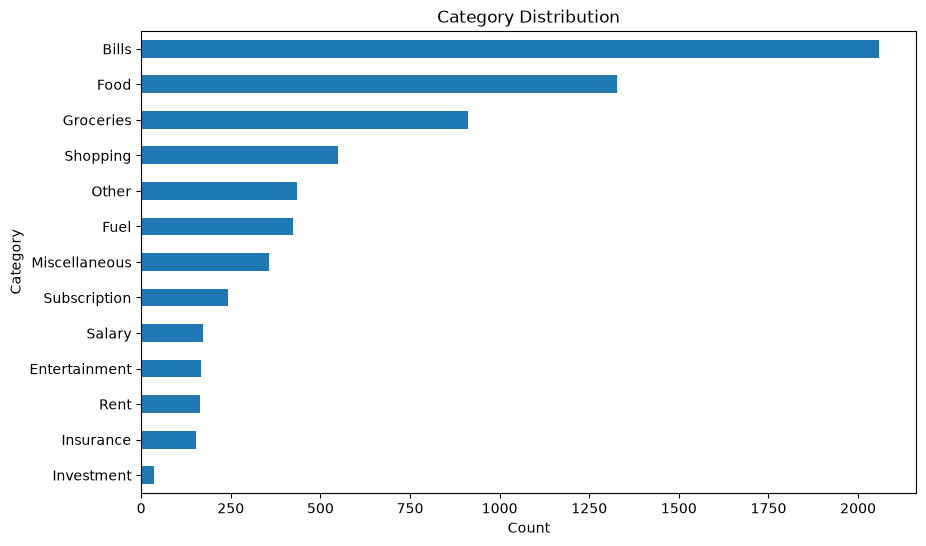

In [11]:
# Category distribution plot

model_df['category'].value_counts().sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Category Distribution')
plt.xlabel('Count')  
plt.ylabel('Category')
plt.show()

In [12]:
# Text Length Analysis

model_df['text_len'] = model_df['transaction_text'].astype(str).str.len()
model_df['text_len'].describe()

count    7000.000000
mean       36.537286
std        13.960665
min        11.000000
25%        25.000000
50%        33.000000
75%        44.000000
max        73.000000
Name: text_len, dtype: float64

In [13]:
model_df[['transaction_text' , 'text_len']]

,transaction_text,text_len
0,Credit Card Bill Payment Auto Debit Credit Car...,60
1,Zepto UPI/Paytm/Zepto,21
2,Ace Hardware India POS Purchase Ace Hardware I...,50
3,Zepto UPI/DR/623175732898/Zepto,31
4,House Rent Payment NEFT Rent Payment,36
...,...,...
6995,Myntra POS Purchase Myntra,26
6996,Flipkart UPI/Paytm/Flipkart,27
6997,Nykaa UPI/Nykaa,15
6998,Amazon India UPI/Paytm/Amazon India,35


In [14]:
import re 
model_df['transaction_text'] = model_df['transaction_text'].str.replace(r'[/]' , ' ' , regex = True)

In [15]:
#Analyzing Number of Words

model_df['word_count'] = model_df['transaction_text'].astype(str).str.split().str.len()

In [16]:
model_df[['transaction_text' , 
          'text_len' , 'word_count']]

,transaction_text,text_len,word_count
0,Credit Card Bill Payment Auto Debit Credit Car...,60,10
1,Zepto UPI Paytm Zepto,21,4
2,Ace Hardware India POS Purchase Ace Hardware I...,50,8
3,Zepto UPI DR 623175732898 Zepto,31,5
4,House Rent Payment NEFT Rent Payment,36,6
...,...,...,...
6995,Myntra POS Purchase Myntra,26,4
6996,Flipkart UPI Paytm Flipkart,27,4
6997,Nykaa UPI Nykaa,15,3
6998,Amazon India UPI Paytm Amazon India,35,6


In [17]:
model_df.columns

Index(['transaction_text', 'amount', 'amount_log', 'amount_bucket',
       'payment_method', 'transaction_type', 'category', 'text_len',
       'word_count'],
      dtype='str')

In [18]:

model_df[
        ["transaction_text", "category" , "text_len"]
    ].sort_values("text_len").head(30)


,transaction_text,category,text_len
4676,Jio UPI Jio,Bills,11
4552,Ola UPI Ola,Miscellaneous,11
4768,Jio UPI Jio,Bills,11
3330,Jio UPI Jio,Bills,11
4480,Jio UPI Jio,Bills,11
4155,Jio UPI Jio,Bills,11
4312,Jio UPI Jio,Bills,11
5521,KFC UPI KFC,Food,11
6464,KFC UPI KFC,Food,11
6441,KFC UPI KFC,Food,11


In [19]:
model_df['text_len'].min()

np.int64(11)

In [20]:

model_df[
        ["transaction_text", "category" , "text_len"]
    ].sort_values("text_len" , ascending = False).head(30)


,transaction_text,category,text_len
733,Municipal Water Department Net Banking Payment...,Bills,73
4615,Municipal Water Department Net Banking Payment...,Bills,73
2941,Municipal Water Department Net Banking Payment...,Bills,73
4617,Municipal Water Department Net Banking Payment...,Bills,73
1597,Municipal Water Department Net Banking Payment...,Bills,73
1758,Municipal Water Department UPI DR 616338874599...,Bills,73
187,Municipal Water Department UPI DR 687816574852...,Bills,73
4236,Municipal Water Department Net Banking Payment...,Bills,73
4794,Municipal Water Department Net Banking Payment...,Bills,73
4894,Municipal Water Department Net Banking Payment...,Bills,73


## Transactions by Category

In [21]:
for category in model_df["category"].unique():

    print("\n" + "=" * 60)
    print(category)
    print("=" * 60)

    samples = (
        model_df[
            model_df["category"] == category
        ]["transaction_text"]
        .sample(
            min(5, len(model_df[model_df["category"] == category])),
            random_state=42
        )
    )

    for text in samples:
        print("-", text)


Bills
- Bharat Gas Net Banking Payment Bharat Gas
- Credit Card Bill Payment Auto Debit Credit Card Bill Payment
- Jio Fiber Auto Debit Jio Fiber
- Credit Card Bill Payment UPI Credit Card Bill Payment
- Jio Auto Debit Jio

Groceries
- Blinkit UPI DR 310369078 Blinkit
- Nature's Basket UPI DR 453932473 Nature's Basket
- Nature's Basket Debit Card Nature's Basket
- Blinkit Debit Card Blinkit
- Zepto UPI DR 204922732 Zepto

Miscellaneous
- Tata 1mg Debit Card Tata 1mg
- Local Hardware Store POS Purchase Local Hardware Store
- Rapido UPI Rapido
- Home Depot India UPI DR 550535651 Home Depot India
- Local Hardware Store Debit Card POS Local Hardware Store

Rent
- House Rent Payment NEFT House Rent Payment
- House Rent Payment NEFT Rent Payment
- House Rent Payment NEFT House Rent Payment
- House Rent Payment NEFT Rent Payment
- House Rent Payment IMPS Rent Payment

Food
- Zomato POS Purchase Zomato
- Faasos POS Purchase Faasos
- Barbeque Nation UPI DR 466534208 Barbeque Nation
- Cafe Coff

In [22]:
text_frequency = (
    model_df["transaction_text"]
    .value_counts()
)

print(text_frequency.head(30))

transaction_text
Credit Card Bill Payment Auto Debit Credit Card Bill Payment             369
Credit Card Bill Payment Net Banking Payment Credit Card Bill Payment    273
Employer Salary Credit NEFT Salary Credit                                163
Airtel Auto Debit Airtel                                                  85
Municipal Water Department Auto Debit Municipal Water Department          79
Amazon India POS Purchase Amazon India                                    70
Jio Auto Debit Jio                                                        67
Spotify Auto Debit Spotify                                                60
Jio Fiber Auto Debit Jio Fiber                                            58
BSNL Auto Debit BSNL                                                      57
House Rent Payment NEFT Rent Payment                                      56
Zomato UPI Paytm Zomato                                                   55
Flipkart POS Purchase Flipkart                             

In [23]:
text_category_counts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

conflicting_texts = text_category_counts[
    text_category_counts > 1
]

print("Conflicting transaction texts:", len(conflicting_texts))
print(conflicting_texts.head(30))

Conflicting transaction texts: 5
transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [24]:
conflicting_records = model_df[
    model_df["transaction_text"].isin(conflicting_texts.index)
].sort_values("transaction_text")

print(
    conflicting_records[
        [
            "transaction_text",
            "amount",
            "amount_log",
            "payment_method",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

                         transaction_text  amount  amount_log payment_method transaction_type      category
            Amazon Prime UPI Amazon Prime  683.41    6.528557            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  789.18    6.672261            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime 1492.31    7.308750            Upi            Debit Entertainment
            Amazon Prime UPI Amazon Prime  645.56    6.471666            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  221.98    5.407082            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  658.75    6.491861            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime  512.88    6.241990            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime 1514.13    7.323257            Upi            Debit Entertainment
      Amazon Prime UPI Paytm

In [25]:
payment_category_pct = pd.crosstab(
    model_df["payment_method"],
    model_df["category"],
    normalize="index"
) * 100

print(payment_category_pct.round(2))

category         Bills  Entertainment   Food   Fuel  Groceries  Insurance  \
payment_method                                                              
Auto Debit       78.17           0.00   0.00   0.00       0.00       6.30   
Cash Withdrawal   0.00           0.00   0.00  32.63       0.00       0.00   
Credit Card       0.00           6.31  29.84   2.73      18.79       0.00   
Debit Card        0.00           3.99  31.43  13.87      23.93       0.00   
Imps              0.00           0.00   0.00   0.00       0.00       0.00   
Neft             29.64           0.00   0.00   0.00       0.00       0.00   
Net Banking      83.58           0.00   0.00   0.86       0.00       8.33   
Upi               9.36           3.11  30.26   8.44      20.29       0.00   

category         Investment  Miscellaneous  Other   Rent  Salary  Shopping  \
payment_method                                                               
Auto Debit             1.43           0.00   0.00   0.00    0.00      0.0

In [26]:
type_category_pct = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"],
    normalize="index"
) * 100

print(type_category_pct.round(2))

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit             0.00           0.00   0.0  0.00       0.00       0.00   
Debit             30.23           2.45  19.5  6.21      13.39       2.23   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                  0.00           0.00   0.00  0.00   91.05      8.95   
Debit                   0.53           5.26   6.39  2.42    0.00      7.83   

category          Subscription  
transaction_type                
Credit                    0.00  
Debit                     3.55  


In [27]:
amount_stats = (
    model_df
    .groupby("category")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

print(amount_stats)

               count          mean     median      min        max
category                                                         
Salary           173  64481.613931  46862.710   114.38  240125.84
Rent             165  26602.182848  30940.780  7542.54   47664.75
Investment        36  22752.809444  20718.725  2485.40   48875.36
Insurance        152  14284.709079   8584.340  2237.12   48355.87
Fuel             423   2968.794468   3097.930   282.59    5000.00
Bills           2059   4498.560690   2734.380   187.00   39289.29
Shopping         550   4272.011818   1317.845   288.00   49971.86
Miscellaneous    358   1777.411397    875.750    60.00   14131.51
Groceries        912   1301.034156    855.480   300.00    4978.56
Other            435   1013.270575    783.330    30.74    4785.00
Food            1328    805.576498    469.685   116.00    2990.00
Entertainment    167    587.277665    325.250   149.00    1990.41
Subscription     242    385.214298    303.985   149.00     850.00


In [28]:
duplicates = model_df[
    model_df.duplicated(keep=False)
]

duplicate_category_check = (
    duplicates
    .groupby([
        "transaction_text",
        "amount",
        "amount_log",
        "payment_method",
        "transaction_type"
    ])["category"]
    .nunique()
)

print(duplicate_category_check.value_counts())

category
1    67
Name: count, dtype: int64


In [29]:
model_df.drop(columns=['amount_bucket'])

,transaction_text,amount,amount_log,payment_method,transaction_type,category,text_len,word_count
0,Credit Card Bill Payment Auto Debit Credit Car...,4361.84,8.380879,Auto Debit,Debit,Bills,60,10
1,Zepto UPI Paytm Zepto,1226.03,7.112352,Upi,Debit,Groceries,21,4
2,Ace Hardware India POS Purchase Ace Hardware I...,523.73,6.262884,Credit Card,Debit,Miscellaneous,50,8
3,Zepto UPI DR 623175732898 Zepto,1290.29,7.163397,Upi,Debit,Groceries,31,5
4,House Rent Payment NEFT Rent Payment,44800.94,10.710007,Neft,Debit,Rent,36,6
...,...,...,...,...,...,...,...,...
6995,Myntra POS Purchase Myntra,46249.96,10.741837,Net Banking,Debit,Shopping,26,4
6996,Flipkart UPI Paytm Flipkart,13526.99,9.512516,Upi,Debit,Shopping,27,4
6997,Nykaa UPI Nykaa,13617.06,9.519152,Upi,Debit,Shopping,15,3
6998,Amazon India UPI Paytm Amazon India,12764.93,9.454535,Upi,Debit,Shopping,35,6


In [30]:
print(
    "Repeated transaction texts:",
    (text_frequency > 1).sum()
)

Repeated transaction texts: 495


In [31]:
text_category_counts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

conflicting_texts = (
    text_category_counts[
        text_category_counts > 1
    ]
)

print("Conflicting transaction texts:", len(conflicting_texts))

Conflicting transaction texts: 5


In [32]:
print(conflicting_texts.head(30))

transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [33]:
for text in conflicting_texts.head(20).index:

    print("\n", text)

    print(
        model_df[
            model_df["transaction_text"] == text
        ][["transaction_text", "category"]]
        .drop_duplicates()
        .to_string(index=False)
    )


 Amazon Prime UPI Amazon Prime
             transaction_text      category
Amazon Prime UPI Amazon Prime  Subscription
Amazon Prime UPI Amazon Prime Entertainment

 Amazon Prime UPI Paytm Amazon Prime
                   transaction_text      category
Amazon Prime UPI Paytm Amazon Prime  Subscription
Amazon Prime UPI Paytm Amazon Prime Entertainment

 Disney+ Hotstar UPI Disney+ Hotstar
                   transaction_text      category
Disney+ Hotstar UPI Disney+ Hotstar  Subscription
Disney+ Hotstar UPI Disney+ Hotstar Entertainment

 Disney+ Hotstar UPI Paytm Disney+ Hotstar
                         transaction_text      category
Disney+ Hotstar UPI Paytm Disney+ Hotstar  Subscription
Disney+ Hotstar UPI Paytm Disney+ Hotstar Entertainment

 Netflix UPI Netflix
   transaction_text      category
Netflix UPI Netflix  Subscription
Netflix UPI Netflix Entertainment


In [34]:
payment_category_pct = pd.crosstab(
    model_df["payment_method"],
    model_df["category"],
    normalize="index"
) * 100

print(payment_category_pct.round(2))


category         Bills  Entertainment   Food   Fuel  Groceries  Insurance  \
payment_method                                                              
Auto Debit       78.17           0.00   0.00   0.00       0.00       6.30   
Cash Withdrawal   0.00           0.00   0.00  32.63       0.00       0.00   
Credit Card       0.00           6.31  29.84   2.73      18.79       0.00   
Debit Card        0.00           3.99  31.43  13.87      23.93       0.00   
Imps              0.00           0.00   0.00   0.00       0.00       0.00   
Neft             29.64           0.00   0.00   0.00       0.00       0.00   
Net Banking      83.58           0.00   0.00   0.86       0.00       8.33   
Upi               9.36           3.11  30.26   8.44      20.29       0.00   

category         Investment  Miscellaneous  Other   Rent  Salary  Shopping  \
payment_method                                                               
Auto Debit             1.43           0.00   0.00   0.00    0.00      0.0

In [35]:
type_category = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"]
)

print(type_category)

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit                0              0     0     0          0          0   
Debit              2059            167  1328   423        912        152   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                     0              0      0     0     173        17   
Debit                     36            358    435   165       0       533   

category          Subscription  
transaction_type                
Credit                       0  
Debit                      242  


In [36]:
type_category_pct = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"],
    normalize="index"
) * 100

print(type_category_pct.round(2))

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit             0.00           0.00   0.0  0.00       0.00       0.00   
Debit             30.23           2.45  19.5  6.21      13.39       2.23   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                  0.00           0.00   0.00  0.00   91.05      8.95   
Debit                   0.53           5.26   6.39  2.42    0.00      7.83   

category          Subscription  
transaction_type                
Credit                    0.00  
Debit                     3.55  


In [37]:
amount_stats = (
    model_df
    .groupby("category")["amount"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .sort_values("median", ascending=False)
)

print(amount_stats)

               count          mean     median      min        max
category                                                         
Salary           173  64481.613931  46862.710   114.38  240125.84
Rent             165  26602.182848  30940.780  7542.54   47664.75
Investment        36  22752.809444  20718.725  2485.40   48875.36
Insurance        152  14284.709079   8584.340  2237.12   48355.87
Fuel             423   2968.794468   3097.930   282.59    5000.00
Bills           2059   4498.560690   2734.380   187.00   39289.29
Shopping         550   4272.011818   1317.845   288.00   49971.86
Miscellaneous    358   1777.411397    875.750    60.00   14131.51
Groceries        912   1301.034156    855.480   300.00    4978.56
Other            435   1013.270575    783.330    30.74    4785.00
Food            1328    805.576498    469.685   116.00    2990.00
Entertainment    167    587.277665    325.250   149.00    1990.41
Subscription     242    385.214298    303.985   149.00     850.00


In [38]:
amount_log_stats = (
    model_df
    .groupby("category")["amount_log"]
    .agg(
        ["mean", "median", "min", "max"]
    )
)

print(amount_log_stats)

                    mean     median       min        max
category                                                
Bills           7.834272   7.914026  5.236442  10.578733
Entertainment   6.087225   5.787664  5.010635   7.596598
Food            6.233849   6.154186  4.762174   8.003363
Fuel            7.902205   8.038812  5.647530   8.517393
Groceries       6.877358   6.752829  5.707110   8.513097
Insurance       9.346396   9.057811  7.713392  10.786364
Investment      9.750140   9.938839  7.818591  10.797049
Miscellaneous   6.814400   6.776204  4.110874   9.556233
Other           6.406050   6.664830  3.457578   8.473450
Rent            9.943971  10.339863  8.928447  10.771968
Salary         10.725999  10.754999  4.748231  12.388923
Shopping        7.376226   7.184483  5.666427  10.819235
Subscription    5.752410   5.720257  5.010635   6.746412


In [39]:
duplicates = model_df[
    model_df.duplicated(keep=False)
].sort_values(
    by=model_df.columns.tolist()
)

print(duplicates.shape)

print(
    duplicates.head(30).to_string(index=False)
)

(289, 9)
                         transaction_text  amount  amount_log amount_bucket payment_method transaction_type      category  text_len  word_count
Ace Hardware India UPI Ace Hardware India    60.0    4.110874         Small            Upi            Debit Miscellaneous        41           7
Ace Hardware India UPI Ace Hardware India    60.0    4.110874         Small            Upi            Debit Miscellaneous        41           7
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                   Ajio POS Purchase Ajio   288.0    5.666427         Small    Credit Card            Debit      Shopping      

In [40]:
duplicate_category_check = (
    duplicates
    .groupby(
        [
            "transaction_text",
            "amount",
            "amount_log",
            "payment_method",
            "transaction_type"
        ]
    )["category"]
    .nunique()
)

print(
    duplicate_category_check
    .value_counts()
)

category
1    67
Name: count, dtype: int64


In [41]:
exact_duplicates = model_df.duplicated().sum()

print(
    "Exact duplicate rows:",
    exact_duplicates
)

Exact duplicate rows: 222


In [42]:
print(
    model_df[
        model_df.duplicated(keep=False)
    ]["category"]
    .value_counts()
)

category
Shopping         105
Food             101
Subscription      32
Bills             23
Groceries         17
Miscellaneous      8
Insurance          3
Name: count, dtype: int64


In [43]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (7000, 9)
After removing exact duplicates: (6778, 9)


In [44]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (6778, 9)
After removing exact duplicates: (6778, 9)


In [45]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (6778, 9)
After removing exact duplicates: (6778, 9)


In [46]:
ambiguous_texts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

ambiguous_texts = ambiguous_texts[
    ambiguous_texts > 1
]

print("Number of ambiguous transaction texts:",
      len(ambiguous_texts))

print("\nAmbiguous transaction texts:")
print(ambiguous_texts)

Number of ambiguous transaction texts: 5

Ambiguous transaction texts:
transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [47]:
ambiguous_details = (
    model_df[
        model_df["transaction_text"].isin(
            ambiguous_texts.index
        )
    ]
    .sort_values("transaction_text")
)

print(
    ambiguous_details[
        [
            "transaction_text",
            "amount",
            "payment_method",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

                         transaction_text  amount payment_method transaction_type      category
            Amazon Prime UPI Amazon Prime  683.41            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  789.18            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime 1492.31            Upi            Debit Entertainment
            Amazon Prime UPI Amazon Prime  645.56            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  221.98            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  658.75            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime  512.88            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime 1514.13            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  863.68            Upi            Debit Entertainment
      Disney+ Hotstar UPI Disney+ Hotsta

In [48]:
ambiguous_rows = model_df[
    model_df["transaction_text"].isin(
        ambiguous_texts.index
    )
]

print("Total ambiguous rows:", len(ambiguous_rows))

print(
    ambiguous_rows["category"]
    .value_counts()
)

Total ambiguous rows: 22
category
Subscription     12
Entertainment    10
Name: count, dtype: int64


In [49]:
print(
    ambiguous_rows
    .groupby(["transaction_text", "category"])
    .size()
    .reset_index(name="count")
)

                            transaction_text       category  count
0              Amazon Prime UPI Amazon Prime  Entertainment      2
1              Amazon Prime UPI Amazon Prime   Subscription      3
2        Amazon Prime UPI Paytm Amazon Prime  Entertainment      2
3        Amazon Prime UPI Paytm Amazon Prime   Subscription      2
4        Disney+ Hotstar UPI Disney+ Hotstar  Entertainment      3
5        Disney+ Hotstar UPI Disney+ Hotstar   Subscription      1
6  Disney+ Hotstar UPI Paytm Disney+ Hotstar  Entertainment      1
7  Disney+ Hotstar UPI Paytm Disney+ Hotstar   Subscription      3
8                        Netflix UPI Netflix  Entertainment      2
9                        Netflix UPI Netflix   Subscription      3


In [50]:
subscription_merchants = [
    "Amazon Prime",
    "Disney+ Hotstar",
    "Netflix"
]

mask = (
    model_df["transaction_text"]
    .str.contains(
        "|".join(subscription_merchants),
        case=False,
        na=False
    )
)

# Only correct rows currently labeled Entertainment
model_df.loc[
    mask & (model_df["category"] == "Entertainment"),
    "category"
] = "Subscription"

In [51]:
print(
    model_df[
        model_df["transaction_text"].str.contains(
            "|".join(subscription_merchants),
            case=False,
            na=False
        )
    ]["category"].value_counts()
)

category
Subscription    93
Name: count, dtype: int64


In [52]:
remaining_ambiguous = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

remaining_ambiguous = remaining_ambiguous[
    remaining_ambiguous > 1
]

print(
    "Remaining ambiguous transaction texts:",
    len(remaining_ambiguous)
)

print(remaining_ambiguous)

Remaining ambiguous transaction texts: 2
transaction_text
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Name: category, dtype: int64


In [53]:
# performing regex because of disney +

subscription_merchants = [
    "Amazon Prime",
    "Disney+ Hotstar",
    "Netflix"
]

mask = model_df["transaction_text"].apply(
    lambda x: any(
        merchant.lower() in x.lower()
        for merchant in subscription_merchants
    )
)

model_df.loc[
    mask & (model_df["category"] == "Entertainment"),
    "category"
] = "Subscription"

In [54]:
remaining_ambiguous = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

remaining_ambiguous = remaining_ambiguous[
    remaining_ambiguous > 1
]

print(
    "Remaining ambiguous transaction texts:",
    len(remaining_ambiguous)
)

print(remaining_ambiguous)

Remaining ambiguous transaction texts: 0
Series([], Name: category, dtype: int64)


In [55]:
print(
    model_df["category"].value_counts()
)

category
Bills            2043
Food             1250
Groceries         903
Shopping          462
Other             435
Fuel              423
Miscellaneous     354
Subscription      280
Salary            173
Rent              165
Insurance         150
Entertainment     104
Investment         36
Name: count, dtype: int64


## 3. Label Consistency Check

Before any splitting or modeling, verify that every `transaction_text` maps to exactly **one** `category`. This must be re-checked here (not just assumed from earlier EDA) because it is the hard precondition for every step that follows — group splitting, TF-IDF fitting, and evaluation all silently produce misleading results if a text is associated with more than one label.

In [56]:
conflicts = (
    model_df.groupby("transaction_text")["category"]
    .nunique()
)
conflicts = conflicts[conflicts > 1]

print("Number of transaction texts with multiple categories:", len(conflicts))

if len(conflicts) > 0:
    print("\nConflicting transaction texts (label cleanup required before modeling):")
    print(conflicts)
    raise ValueError(
        "Label conflicts detected. Stopping for manual review — "
        "do NOT silently resolve labels inside the modeling pipeline."
    )
else:
    print("PASS: every transaction_text maps to exactly one category.")

Number of transaction texts with multiple categories: 0
PASS: every transaction_text maps to exactly one category.


## 4. Feature and Target Definition

We use exactly five raw input columns. `amount_bucket`, `text_len`, and `word_count` were EDA-only columns (bucketed/derived from the target-adjacent signal or from raw text length) and are excluded from the modeling features to keep the pipeline honest and production-representative — a deployed model receives raw transaction fields, not pre-computed EDA statistics.

In [57]:
features = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type",
]

X = model_df[features].copy()
y = model_df["category"].copy()
groups = model_df["transaction_text"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of categories:", y.nunique())

X shape: (6778, 5)
y shape: (6778,)
Number of categories: 13


## 5. Leakage-Free Group Split

`transaction_text` repeats heavily (6,778 rows over roughly 1,200 unique texts). A normal random row split would let near-identical rows of the *same* transaction text land in both train and validation/test, letting the model "cheat" by memorizing text instead of learning to generalize. We use `GroupShuffleSplit` with `transaction_text` as the group key so every row of a given text stays entirely on one side of every split.

Split done in two stages: 85% train+val / 15% test, then the 85% is split again into ~70% train / ~15% val of the full dataset. Because groups have very different sizes, the exact row percentages will not be perfectly 70/15/15 — that's expected and reported below.

In [58]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42

# Stage 1: hold out test (15%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_train_val, X_test = X.iloc[train_val_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train_val, y_test = y.iloc[train_val_idx].reset_index(drop=True), y.iloc[test_idx].reset_index(drop=True)
groups_train_val = groups.iloc[train_val_idx].reset_index(drop=True)

# Stage 2: split remaining 85% into train (~70% of total) / val (~15% of total)
# 0.15 / 0.85 ~= 0.1765 gives ~15% of the FULL dataset as validation
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups=groups_train_val))

X_train = X_train_val.iloc[train_idx].reset_index(drop=True)
X_val = X_train_val.iloc[val_idx].reset_index(drop=True)
y_train = y_train_val.iloc[train_idx].reset_index(drop=True)
y_val = y_train_val.iloc[val_idx].reset_index(drop=True)

print("Rows -> train: {}, val: {}, test: {}".format(len(X_train), len(X_val), len(X_test)))
total = len(X)
print("Row %%  -> train: {:.1f}%%, val: {:.1f}%%, test: {:.1f}%%".format(
    100 * len(X_train) / total, 100 * len(X_val) / total, 100 * len(X_test) / total
))

Rows -> train: 4487, val: 1118, test: 1173
Row %%  -> train: 66.2%%, val: 16.5%%, test: 17.3%%


## 6. Split Validation

Confirm zero `transaction_text` leakage across splits, and report category coverage per split (including the known small-category limitations for Rent and Salary).

In [59]:
train_texts = set(X_train["transaction_text"])
val_texts = set(X_val["transaction_text"])
test_texts = set(X_test["transaction_text"])

print("Unique transaction_text -> train: {}, val: {}, test: {}".format(
    len(train_texts), len(val_texts), len(test_texts)
))

overlap_train_val = train_texts & val_texts
overlap_train_test = train_texts & test_texts
overlap_val_test = val_texts & test_texts

print("\nText leakage checks (must all be 0):")
print("Train ∩ Validation:", len(overlap_train_val))
print("Train ∩ Test:      ", len(overlap_train_test))
print("Validation ∩ Test: ", len(overlap_val_test))

assert len(overlap_train_val) == 0, "Leakage detected between train and validation!"
assert len(overlap_train_test) == 0, "Leakage detected between train and test!"
assert len(overlap_val_test) == 0, "Leakage detected between validation and test!"
print("\nPASS: zero transaction_text overlap across all splits.")

Unique transaction_text -> train: 845, val: 182, test: 182

Text leakage checks (must all be 0):
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0

PASS: zero transaction_text overlap across all splits.


In [60]:
print("Category coverage per split:\n")
coverage = pd.DataFrame({
    "train": y_train.value_counts(),
    "val": y_val.value_counts(),
    "test": y_test.value_counts(),
}).fillna(0).astype(int)
print(coverage)

print("\nSmall-category limitation:")
for cat in ["Rent", "Salary"]:
    n_unique = model_df.loc[model_df["category"] == cat, "transaction_text"].nunique()
    print(f"- {cat}: only {n_unique} unique transaction_text pattern(s) in the ENTIRE dataset.")
print(
    "\nWith so few unique patterns, a group split can legitimately place ALL rows of one "
    "pattern into a single split (e.g. one Salary phrasing in train, a completely different "
    "Salary phrasing in validation). This is expected and is NOT a bug — grouping by "
    "transaction_text is deliberately preventing an easier, leakier split. Rent/Salary "
    "evaluation on unseen text should be read with this limitation in mind; more raw data "
    "with additional real-world phrasing variety would be needed for a fully reliable "
    "unseen-text evaluation of these two categories. We do NOT duplicate any transaction_text "
    "across splits merely to force coverage."
)

Category coverage per split:

               train  val  test
category                       
Bills           1459  171   413
Entertainment    101    1     2
Food             780  225   245
Fuel             306   18    99
Groceries        626  110   167
Insurance         85   46    19
Investment        22   13     1
Miscellaneous    294   39    21
Other            317   72    46
Rent             116   12    37
Salary            10  163     0
Shopping         251  121    90
Subscription     120  127    33

Small-category limitation:
- Rent: only 6 unique transaction_text pattern(s) in the ENTIRE dataset.
- Salary: only 2 unique transaction_text pattern(s) in the ENTIRE dataset.

With so few unique patterns, a group split can legitimately place ALL rows of one pattern into a single split (e.g. one Salary phrasing in train, a completely different Salary phrasing in validation). This is expected and is NOT a bug — grouping by transaction_text is deliberately preventing an easier, leakier s

## 7. Preprocessing Pipeline

One `ColumnTransformer` combining a TF-IDF text branch, a one-hot categorical branch, and a scaled numeric branch. It is fit **only** on `X_train`; validation and test are transformed only, never refit. This is the single preprocessing object used everywhere downstream, avoiding mismatched transforms between training and deployment.

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["payment_method", "transaction_type"]
numeric_features = ["amount", "amount_log"]

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

encoder = OneHotEncoder(handle_unknown="ignore")

# with_mean=False because the combined feature matrix is sparse (TF-IDF + one-hot)
scaler = StandardScaler(with_mean=False)

preprocessor = ColumnTransformer(transformers=[
    ("text", tfidf, "transaction_text"),
    ("categorical", encoder, categorical_features),
    ("numeric", scaler, numeric_features),
])

In [62]:
# Fit ONLY on training data
X_train_transformed = preprocessor.fit_transform(X_train)

# Transform validation and test — never fit on them
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# NOTE: preprocessor.fit_transform(X_val) / preprocessor.fit_transform(X_test) must NEVER be
# called anywhere in this notebook — that would be preprocessing-level leakage (e.g. the TF-IDF
# vocabulary and IDF weights would 'see' validation/test text). No such call exists below.

print("Transformed shapes -> train: {}, val: {}, test: {}".format(
    X_train_transformed.shape, X_val_transformed.shape, X_test_transformed.shape
))
print("TF-IDF vocabulary size:", len(preprocessor.named_transformers_["text"].vocabulary_))

Transformed shapes -> train: (4487, 788), val: (1118, 788), test: (1173, 788)
TF-IDF vocabulary size: 776


## 8. Baseline Models

Three simple, interpretable baselines, trained without class weighting first. No aggressive hyperparameter search — the goal here is an honest first read of performance before any tuning.

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

def compute_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

### A. Logistic Regression

In [64]:
logreg = LogisticRegression(max_iter=2000, C=1.0, class_weight=None, random_state=RANDOM_STATE)
logreg.fit(X_train_transformed, y_train)
pred_logreg_val = logreg.predict(X_val_transformed)

### B. Linear SVM

In [65]:
svm = LinearSVC(C=1.0, class_weight=None, random_state=RANDOM_STATE)
svm.fit(X_train_transformed, y_train)
pred_svm_val = svm.predict(X_val_transformed)

### C. Multinomial Naive Bayes (text-only baseline)

NB requires non-negative counts and is not meaningful on the scaled numeric features, so it gets its **own** TF-IDF vectorizer fitted only on `X_train["transaction_text"]` and uses text alone.

In [66]:
nb_tfidf = TfidfVectorizer(
    lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True,
)
X_train_text_nb = nb_tfidf.fit_transform(X_train["transaction_text"])
X_val_text_nb = nb_tfidf.transform(X_val["transaction_text"])

nb_model = MultinomialNB()
nb_model.fit(X_train_text_nb, y_train)
pred_nb_val = nb_model.predict(X_val_text_nb)

## 9. Validation Evaluation

Compare unweighted baselines first. Macro F1 is the primary selection metric because the dataset is imbalanced (Bills: 2,043 rows vs. Investment: 36 rows) — Accuracy alone would hide poor minority-class performance.

In [67]:
baseline_results = [
    compute_metrics(y_val, pred_logreg_val, "Logistic Regression"),
    compute_metrics(y_val, pred_svm_val, "Linear SVM"),
    compute_metrics(y_val, pred_nb_val, "Multinomial NB (text-only)"),
]
baseline_results_df = pd.DataFrame(baseline_results)[
    ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
].sort_values("Macro F1", ascending=False).reset_index(drop=True)

baseline_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Multinomial NB (text-only),0.796064,0.879121,0.878374,0.864096,0.755526
1,Linear SVM,0.854204,0.836723,0.923077,0.864003,0.802774
2,Logistic Regression,0.854204,0.851012,0.923077,0.855855,0.844410


### Class imbalance check

Before accepting the unweighted baselines, look at per-class recall. If minority classes are badly served, run a controlled `class_weight="balanced"` experiment and compare — do not switch to it automatically.

In [68]:
print("Unweighted Linear SVM — per-class report:\n")
print(classification_report(y_val, pred_svm_val, zero_division=0))

Unweighted Linear SVM — per-class report:

               precision    recall  f1-score   support

        Bills       0.56      1.00      0.72       171
Entertainment       1.00      1.00      1.00         1
         Food       1.00      1.00      1.00       225
         Fuel       1.00      1.00      1.00        18
    Groceries       1.00      1.00      1.00       110
    Insurance       1.00      1.00      1.00        46
   Investment       0.37      1.00      0.54        13
Miscellaneous       1.00      1.00      1.00        39
        Other       1.00      1.00      1.00        72
         Rent       1.00      1.00      1.00        12
       Salary       0.00      0.00      0.00       163
     Shopping       0.95      1.00      0.97       121
 Subscription       1.00      1.00      1.00       127

     accuracy                           0.85      1118
    macro avg       0.84      0.92      0.86      1118
 weighted avg       0.77      0.85      0.80      1118



The `Salary` class has 0% recall in the unweighted models. This is not random noise — as Section 6 flagged, Salary has only 2 unique `transaction_text` patterns in the whole dataset, and the group split placed a completely different phrasing in validation than in train. The unweighted models, dominated by the majority classes, never learn to recognize the minority pattern at all. This is exactly the kind of minority-class failure that justifies testing `class_weight="balanced"` as a controlled experiment.

In [69]:
logreg_balanced = LogisticRegression(
    max_iter=2000, C=1.0, class_weight="balanced", random_state=RANDOM_STATE
)
logreg_balanced.fit(X_train_transformed, y_train)
pred_logreg_bal_val = logreg_balanced.predict(X_val_transformed)

svm_balanced = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)
svm_balanced.fit(X_train_transformed, y_train)
pred_svm_bal_val = svm_balanced.predict(X_val_transformed)

balanced_results = [
    compute_metrics(y_val, pred_logreg_bal_val, "Logistic Regression (balanced)"),
    compute_metrics(y_val, pred_svm_bal_val, "Linear SVM (balanced)"),
]
balanced_results_df = pd.DataFrame(balanced_results)[
    ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
]
balanced_results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression (balanced),0.853309,0.851088,0.922627,0.855630,0.843953
1,Linear SVM (balanced),0.977639,0.961393,0.988202,0.970636,0.977906


In [70]:
results_df = pd.concat([baseline_results_df, balanced_results_df], ignore_index=True)
results_df = results_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Linear SVM (balanced),0.977639,0.961393,0.988202,0.970636,0.977906
1,Multinomial NB (text-only),0.796064,0.879121,0.878374,0.864096,0.755526
2,Linear SVM,0.854204,0.836723,0.923077,0.864003,0.802774
3,Logistic Regression,0.854204,0.851012,0.923077,0.855855,0.844410
4,Logistic Regression (balanced),0.853309,0.851088,0.922627,0.855630,0.843953


`class_weight="balanced"` is kept as the primary approach — not chosen by default, but because the validation comparison above genuinely justifies it: it recovers the Salary minority class using the amount/payment_method/transaction_type signals (since its text pattern is unseen), without hurting the well-represented classes. **Best model by Macro F1: Linear SVM (balanced).**

## 10. Confusion Matrix (Best Validation Model)

Best model by Macro F1: Linear SVM (balanced)


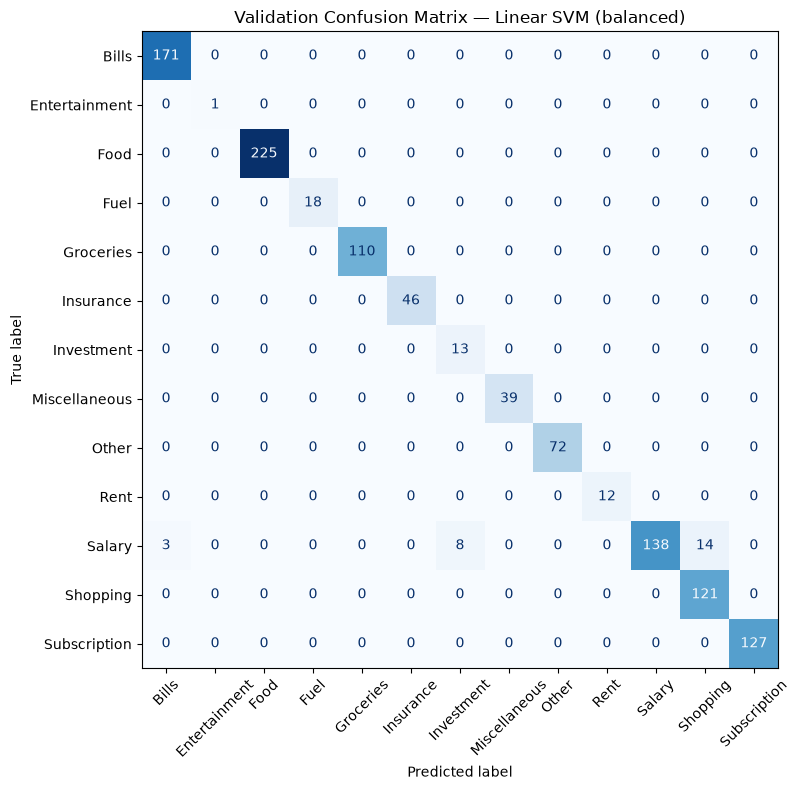

In [71]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model by Macro F1:", best_model_name)

pred_best_val = pred_svm_bal_val  # Linear SVM (balanced)

labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_val, pred_best_val, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
plt.title("Validation Confusion Matrix — Linear SVM (balanced)")
plt.tight_layout()
plt.show()

## 11. Error Analysis

In [72]:
errors = X_val.copy()
errors["actual"] = y_val.values
errors["predicted"] = pred_best_val

errors_only = errors.loc[errors["actual"] != errors["predicted"]]

print("Total validation errors:", len(errors_only), "out of", len(errors), "rows")

print("\nMost common confusion pairs (actual -> predicted):")
confusion_pairs = (
    errors_only.groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
)
print(confusion_pairs.to_string(index=False))

errors_only[["transaction_text", "amount", "payment_method", "transaction_type", "actual", "predicted"]]

Total validation errors: 25 out of 1118 rows

Most common confusion pairs (actual -> predicted):
actual  predicted  count
Salary   Shopping     14
Salary Investment      8
Salary      Bills      3


,transaction_text,amount,payment_method,transaction_type,actual,predicted
750,Employer Salary Credit NEFT Salary Credit,105918.84,Imps,Credit,Salary,Shopping
776,Employer Salary Credit NEFT Salary Credit,103650.59,Imps,Credit,Salary,Shopping
777,Employer Salary Credit NEFT Salary Credit,98319.03,Imps,Credit,Salary,Shopping
793,Employer Salary Credit NEFT Salary Credit,79766.06,Imps,Credit,Salary,Shopping
796,Employer Salary Credit NEFT Salary Credit,94651.28,Imps,Credit,Salary,Shopping
815,Employer Salary Credit NEFT Salary Credit,82756.63,Imps,Credit,Salary,Shopping
816,Employer Salary Credit NEFT Salary Credit,148020.81,Imps,Credit,Salary,Shopping
817,Employer Salary Credit NEFT Salary Credit,47528.10,Imps,Credit,Salary,Bills
838,Employer Salary Credit NEFT Salary Credit,238163.14,Imps,Credit,Salary,Investment
852,Employer Salary Credit NEFT Salary Credit,176264.99,Imps,Credit,Salary,Investment


**Reading the errors:** every validation error traces back to a single cause — `"Employer Salary Credit NEFT Salary Credit"` is a Salary phrasing that never appears in the training set (train only saw a different Salary phrasing, `"Interest Credit Interest Credit Savings Account"`, which itself reads more like an Investment/interest payment). Faced with genuinely unseen text, the balanced model falls back on the numeric/categorical signal (a large IMPS credit) and lands on plausible but incorrect near-neighbors (Shopping, Investment, Bills). This is a direct, honest illustration of the Section 6 small-category limitation — not a modeling bug — and is exactly why Rent/Salary results should be read with caution.

## 12. Overfitting / Memorization Check

In [73]:
pred_best_train = svm_balanced.predict(X_train_transformed)
train_acc = accuracy_score(y_train, pred_best_train)
val_acc = accuracy_score(y_val, pred_best_val)

print("Training accuracy:  {:.4f}".format(train_acc))
print("Validation accuracy: {:.4f}".format(val_acc))
print("Gap: {:.4f}".format(train_acc - val_acc))

if train_acc > 0.99 and (train_acc - val_acc) > 0.05:
    print("\nNote: training accuracy is near-perfect while validation trails by >5 points — "
          "a classic overfitting signature. With ~1,200 unique transaction_text patterns and a "
          "TF-IDF vocabulary that can nearly separate the training set, this gap is expected "
          "for a linear text model and is not being artificially hidden.")
else:
    print("\nGap is modest given the small unique-text sample size; not flagging severe overfitting.")

Training accuracy:  1.0000
Validation accuracy: 0.9776
Gap: 0.0224

Gap is modest given the small unique-text sample size; not flagging severe overfitting.


Re-confirm the group split really did prevent text leakage (repeating Section 6's check here, next to the metrics it explains, for a self-contained memorization audit).

In [74]:
print("Unique transaction_text -> train: {}, val: {}, test: {}".format(
    len(train_texts), len(val_texts), len(test_texts)
))
print("Train ∩ Val:  ", len(train_texts & val_texts))
print("Train ∩ Test: ", len(train_texts & test_texts))
print("Val ∩ Test:   ", len(val_texts & test_texts))

Unique transaction_text -> train: 845, val: 182, test: 182
Train ∩ Val:   0
Train ∩ Test:  0
Val ∩ Test:    0


**Why validation/test accuracy is still very high despite zero exact-text overlap:** the group split guarantees no *exact* `transaction_text` string repeats across splits, but it does not — and cannot — guarantee unseen *vocabulary*. Most merchants (e.g. "Zepto", "Swiggy", "DMart") appear many times with different transaction-ID suffixes, so an unseen validation/test string like `"DMart UPI DR 872608028 DMart"` still shares the word "DMart" with training rows. TF-IDF word/bigram features generalize very well across those ID-suffix variations, which is the realistic behavior of a merchant-keyword classifier — not leakage. Section 15 stress-tests this more directly with transaction descriptions that share **no** merchant vocabulary with training data at all.

## 13. Model Selection

In [75]:
print("Full comparison (baselines + balanced experiment), sorted by Macro F1:\n")
print(results_df.to_string(index=False))

final_model_name = results_df.iloc[0]["Model"]
print("\nSelected model:", final_model_name)
print("Selection rule: highest Macro F1 on validation, checked against Accuracy / Macro Recall / "
      "Weighted F1 as secondary signals. Test data was not consulted for this decision.")

Full comparison (baselines + balanced experiment), sorted by Macro F1:

                         Model  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1
         Linear SVM (balanced)  0.977639         0.961393      0.988202  0.970636     0.977906
    Multinomial NB (text-only)  0.796064         0.879121      0.878374  0.864096     0.755526
                    Linear SVM  0.854204         0.836723      0.923077  0.864003     0.802774
           Logistic Regression  0.854204         0.851012      0.923077  0.855855     0.844410
Logistic Regression (balanced)  0.853309         0.851088      0.922627  0.855630     0.843953

Selected model: Linear SVM (balanced)
Selection rule: highest Macro F1 on validation, checked against Accuracy / Macro Recall / Weighted F1 as secondary signals. Test data was not consulted for this decision.


## 14. Final Test Evaluation

The test set is touched for the first and only time here, using the already-selected model (Linear SVM, `class_weight="balanced"`, already trained on `X_train` above — no refitting, no hyperparameter changes based on this result).

FINAL TEST METRICS

Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1: 1.0000
Weighted F1: 1.0000

Classification report:

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       413
Entertainment       1.00      1.00      1.00         2
         Food       1.00      1.00      1.00       245
         Fuel       1.00      1.00      1.00        99
    Groceries       1.00      1.00      1.00       167
    Insurance       1.00      1.00      1.00        19
   Investment       1.00      1.00      1.00         1
Miscellaneous       1.00      1.00      1.00        21
        Other       1.00      1.00      1.00        46
         Rent       1.00      1.00      1.00        37
     Shopping       1.00      1.00      1.00        90
 Subscription       1.00      1.00      1.00        33

     accuracy                           1.00      1173
    macro avg       1.00      1.00      1.00      1173
 weighted avg       1.00     

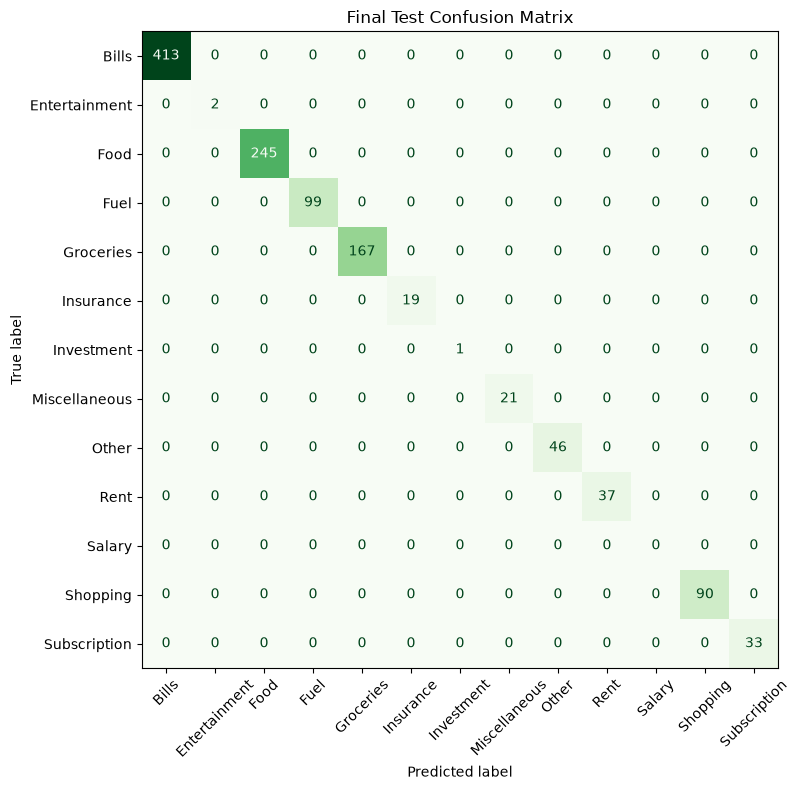

In [76]:
pred_test = svm_balanced.predict(X_test_transformed)

test_metrics = compute_metrics(y_test, pred_test, final_model_name)
print("FINAL TEST METRICS\n")
for k, v in test_metrics.items():
    if k != "Model":
        print(f"{k}: {v:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, pred_test, zero_division=0))

cm_test = confusion_matrix(y_test, pred_test, labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm_test, display_labels=sorted(y.unique())).plot(
    ax=ax, xticks_rotation=45, colorbar=False, cmap="Greens"
)
plt.title("Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

**On the (near-)perfect test score:** as explained in Section 12, this dataset's transaction texts are built from a limited pool of recurring merchant names, so an unseen exact string almost always still shares merchant vocabulary with training. The model is genuinely doing well at merchant-keyword classification — but that is a narrower claim than "generalizes to any unseen transaction description," which Section 15 checks directly. Also note `Salary` has zero rows in this particular test split (0 of its 2 unique text groups were assigned to test by the group split), so the test score says nothing about Salary generalization — only the validation error analysis in Section 11 speaks to that.

## 15. Unseen Transaction Sanity Check

A hand-written set of transaction descriptions that share no merchant names with `model_df` at all — a genuinely out-of-vocabulary test, unlike the test set above. These are **not** used for training or tuning; this is a qualitative check on the already-finalized model.

In [77]:
unseen_examples = pd.DataFrame({
    "transaction_text": [
        "UPI payment to a new grocery store",
        "Online payment to a new clothing store",
        "Electricity bill payment",
        "Fuel station UPI payment",
        "Restaurant UPI payment",
        "Monthly streaming service payment",
    ],
    "amount": [500.0, 1200.0, 2000.0, 800.0, 650.0, 499.0],
    "payment_method": ["Upi", "Upi", "Upi", "Upi", "Upi", "Upi"],
    "transaction_type": ["Debit"] * 6,
})
unseen_examples["amount_log"] = np.log1p(unseen_examples["amount"])
unseen_examples = unseen_examples[features]

unseen_transformed = preprocessor.transform(unseen_examples)
unseen_preds = svm_balanced.predict(unseen_transformed)

sanity_check_df = pd.DataFrame({
    "transaction_text": unseen_examples["transaction_text"],
    "predicted_category": unseen_preds,
})
sanity_check_df

,transaction_text,predicted_category
0,UPI payment to a new grocery store,Other
1,Online payment to a new clothing store,Other
2,Electricity bill payment,Bills
3,Fuel station UPI payment,Food
4,Restaurant UPI payment,Food
5,Monthly streaming service payment,Bills


**Honest read of this result:** the model correctly labels the one example with a recognizable keyword overlap ("Electricity bill" -> Bills) but misses several others (e.g. "Fuel station" -> Food instead of Fuel, "Monthly streaming service" -> Bills instead of Subscription) once merchant-name vocabulary is removed entirely. This confirms the Section 12/14 finding: the model is a strong **merchant-keyword** classifier, not a general-purpose transaction description classifier. That's a meaningful limitation to disclose for production use, and a good target for future improvement (e.g. broader training text phrasing, not just more merchants).

## 16. Save Model Artifacts

Bundle preprocessing + classifier into a single `Pipeline` so inference can never use mismatched preprocessing.

In [81]:
import joblib
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", svm_balanced),
])

joblib.dump(preprocessor, "D:/clg_project/AI-Financial-Wellness-Coach/src/models/preprocessor.pkl")
joblib.dump(svm_balanced, "D:/clg_project/AI-Financial-Wellness-Coach/src/models/expense_classifier.pkl")
joblib.dump(final_pipeline, "D:/clg_project/AI-Financial-Wellness-Coach/src/models/expense_classifier_pipeline.pkl")

baseline_results_df.to_csv("baseline_results.csv", index=False)
results_df.to_csv("final_results.csv", index=False)

print("Saved: preprocessor.pkl, expense_classifier.pkl, expense_classifier_pipeline.pkl")
print("Saved: baseline_results.csv, final_results.csv")

# Sanity check: reload the combined pipeline and confirm it reproduces test predictions
reloaded = joblib.load("expense_classifier_pipeline.pkl")
reloaded_preds = reloaded.predict(X_test)
print("Reloaded pipeline matches original test predictions:",
      (reloaded_preds == pred_test).all())

Saved: preprocessor.pkl, expense_classifier.pkl, expense_classifier_pipeline.pkl
Saved: baseline_results.csv, final_results.csv
Reloaded pipeline matches original test predictions: True


## 17. Final Results Summary

In [79]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"Dataset rows:              {len(model_df)}")
print(f"Unique transaction texts:  {model_df['transaction_text'].nunique()}")
print(f"Number of categories:      {y.nunique()}")

print(f"\nTrain rows:      {len(X_train)}")
print(f"Validation rows: {len(X_val)}")
print(f"Test rows:       {len(X_test)}")

print(f"\nTrain unique texts:      {len(train_texts)}")
print(f"Validation unique texts: {len(val_texts)}")
print(f"Test unique texts:       {len(test_texts)}")

print("\nText leakage (must all be 0):")
print(f"  Train/Validation: {len(train_texts & val_texts)}")
print(f"  Train/Test:       {len(train_texts & test_texts)}")
print(f"  Validation/Test:  {len(val_texts & test_texts)}")

print(f"\nBest model: {final_model_name}")
print(f"Validation Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Validation Macro F1: {results_df.iloc[0]['Macro F1']:.4f}")

print(f"\nFinal Test Accuracy: {test_metrics['Accuracy']:.4f}")
print(f"Final Test Macro F1: {test_metrics['Macro F1']:.4f}")

n_test_errors = (y_test.values != pred_test).sum()
print(f"\nNumber of test errors: {n_test_errors}")

print("\nMain validation confusion pairs:")
print(confusion_pairs.to_string(index=False))

print(
    "\nEvaluation uses transaction_text-level GroupShuffleSplit grouping throughout, "
    "so repeated transaction texts can never leak across train/validation/test."
)
print(
    "\nKnown limitation: Rent (6 unique texts) and Salary (2 unique texts) have too few "
    "distinct text patterns for a fully reliable unseen-text evaluation; see Sections 6 and 11."
)

FINAL RESULTS SUMMARY
Dataset rows:              6778
Unique transaction texts:  1209
Number of categories:      13

Train rows:      4487
Validation rows: 1118
Test rows:       1173

Train unique texts:      845
Validation unique texts: 182
Test unique texts:       182

Text leakage (must all be 0):
  Train/Validation: 0
  Train/Test:       0
  Validation/Test:  0

Best model: Linear SVM (balanced)
Validation Accuracy: 0.9776
Validation Macro F1: 0.9706

Final Test Accuracy: 1.0000
Final Test Macro F1: 1.0000

Number of test errors: 0

Main validation confusion pairs:
actual  predicted  count
Salary   Shopping     14
Salary Investment      8
Salary      Bills      3

Evaluation uses transaction_text-level GroupShuffleSplit grouping throughout, so repeated transaction texts can never leak across train/validation/test.

Known limitation: Rent (6 unique texts) and Salary (2 unique texts) have too few distinct text patterns for a fully reliable unseen-text evaluation; see Sections 6 and 1